# TabNet: Transfer Learning (NGA-West to Himalayan)

- Dataset: NGA-West2 source + Himalayan target (shared periods up to 4.0s)
- Model: TabNet (pytorch-tabnet), source pretraining then transfer fine-tuning

### Tasks
- Phase 1: Load and harmonize source/target datasets
- Phase 2: Build class-mean Vs30 proxy features and preprocess
- Phase 3: Train source TabNet model on NGA-West
- Phase 4: Transfer sweep on Himalayan and select best config
- Phase 5: Final fixed-epoch transfer training
- Phase 6: Evaluate metrics, residuals, and parametric curves
- Phase 7: TabNet native importance and SHAP explainability

### Inputs
- Earthquake Magnitude
- Joyner-Boore Dist. (km)
- Mechanism Based on Rake Angle
- NEHRP_Class_Encoded
- log10_Vs30_proxy (from NEHRP class-mean proxy)
- log10_Rjb

### Outputs
- log10_PGA
- log10 spectral accelerations for shared periods (T0.010S to T4.000S)

In [ ]:
import os
import glob
import json
import itertools
import importlib.util
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Match the dependency strategy used in the previously working tabnet notebook.
dependencies = {
    'shap': 'shap',
    'calamine': 'python-calamine',
    'pytorch_tabnet': 'pytorch-tabnet',
}

for module, package in dependencies.items():
    if importlib.util.find_spec(module) is None:
        print(f'Installing {package} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
    else:
        print(f'{package} already installed.')

from pytorch_tabnet.tab_model import TabNetRegressor
import shap

c:\Users\suggu\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

NGA_FILENAME = 'Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx'
HIM_FILENAME = 'HimData-2.csv'
KAGGLE_DATASET_ROOT = '/kaggle/input/datasets/premsuggu11/nga-west2-seismic-data'

# Try common local roots so this notebook works from both repo root and kaggle/ folder.
LOCAL_DATASET_CANDIDATES = ['dataset', '../dataset']

# Shared class-mean Vs30 mapping used throughout source and transfer workflows.
CLASS_MEAN_VS30 = {'A': 2000.0, 'B': 1130.0, 'C': 560.0, 'D': 270.0, 'E': 120.0}

if os.path.exists('/kaggle/input'):
    nga_candidate = os.path.join(KAGGLE_DATASET_ROOT, NGA_FILENAME)
    him_candidate = os.path.join(KAGGLE_DATASET_ROOT, HIM_FILENAME)
    if os.path.exists(nga_candidate) and os.path.exists(him_candidate):
        NGA_FILE = nga_candidate
        HIM_FILE = him_candidate
    else:
        nga_matches = [m for m in glob.glob('/kaggle/input/**/*.xlsx', recursive=True) if NGA_FILENAME in m]
        him_matches = [m for m in glob.glob('/kaggle/input/**/*.csv', recursive=True) if HIM_FILENAME in m]
        if not nga_matches or not him_matches:
            raise FileNotFoundError('Required NGA/Himalayan files not found under /kaggle/input.')
        NGA_FILE = nga_matches[0]
        HIM_FILE = him_matches[0]
else:
    NGA_FILE = None
    HIM_FILE = None
    for root in LOCAL_DATASET_CANDIDATES:
        nga_try = os.path.join(root, NGA_FILENAME)
        him_try = os.path.join(root, HIM_FILENAME)
        if os.path.exists(nga_try) and os.path.exists(him_try):
            NGA_FILE = nga_try
            HIM_FILE = him_try
            break
    if NGA_FILE is None or HIM_FILE is None:
        raise FileNotFoundError(
            f'Local dataset files not found. Tried roots: {LOCAL_DATASET_CANDIDATES}'
        )

OUTPUT_DIR = '/kaggle/working/results' if os.path.exists('/kaggle/input') else 'results/tabnet-himalaya'
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEST_SIZE = 0.2
VAL_FRAC = 0.15

SOURCE_CONFIG = {
    'n_d': 64,
    'n_steps': 3,
    'momentum': 0.01,
    'lambda_sparse': 0.001,
    'lr': 0.003,
    'batch_size': 256
}

# Full training profile requested.
SOURCE_MAX_EPOCHS = 300
SOURCE_PATIENCE = 60
SWEEP_RUNS = 300
SWEEP_EPOCHS = 50
FINAL_TRANSFER_EPOCHS = 300

# Expanded transfer search space.
TRANSFER_SPACE = {
    'lr': [3e-5, 1e-4, 3e-4, 5e-4, 1e-3, 2e-3, 3e-3, 5e-3],
    'batch_size': [32, 64, 96, 128, 192, 256, 384],
    'lambda_sparse': [0.0, 1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3],
    'unfreeze_tensors': [5, 10, 20, 30, 40, 'all']
}

# Strict GPU-only mode (no CPU fallback).
if not torch.cuda.is_available():
    raise RuntimeError('GPU is required for this notebook, but CUDA is not available in this runtime.')

try:
    _probe = torch.randn((2, 2), device='cuda') * 2.0
    del _probe
    torch.cuda.synchronize()
except Exception as e:
    raise RuntimeError(
        'CUDA is visible but unusable in this runtime. '
        'Use a compatible GPU runtime / PyTorch-CUDA build. Original error: ' + str(e)
    )

device = torch.device('cuda')
TABNET_DEVICE_NAME = 'cuda'

print('PyTorch:', torch.__version__)
print('Device selected:', device)
print('GPU:', torch.cuda.get_device_name(0))
print('NGA file:', NGA_FILE)
print('Himalayan file:', HIM_FILE)
print('Output dir:', OUTPUT_DIR)
print('Training profile:', SOURCE_MAX_EPOCHS, SOURCE_PATIENCE, SWEEP_RUNS, SWEEP_EPOCHS, FINAL_TRANSFER_EPOCHS)
print('Transfer-space size:', len(TRANSFER_SPACE['lr']) * len(TRANSFER_SPACE['batch_size']) * len(TRANSFER_SPACE['lambda_sparse']) * len(TRANSFER_SPACE['unfreeze_tensors']))

PyTorch: 2.6.0+cu124
Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
NGA file: ../dataset\Updated_NGA_West2_Flatfile_RotD50_d050_public_version.xlsx
Himalayan file: ../dataset\HimData-2.csv
Output dir: results/tabnet-himalaya
Training profile: 300 60 300 50 300
Transfer-space size: 3024


In [3]:
def period_to_float(col):
    return float(col[1:-1])

VALID_CLASSES = list(CLASS_MEAN_VS30.keys())
NEHRP_TO_INT = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}

him_df = pd.read_csv(HIM_FILE)
him_df = him_df.rename(columns={
    'Magnitude': 'Earthquake Magnitude',
    'Joyner_Boore_Rjb': 'Joyner-Boore Dist. (km)',
    'Fault_Mechanisc': 'Mechanism Based on Rake Angle',
    'PGA': 'PGA (g)'
})
him_df['NEHRP_Class'] = him_df['Soil_site_class'].astype(str).str.strip().str.upper()
him_df['NEHRP_Class'] = him_df['NEHRP_Class'].where(him_df['NEHRP_Class'].isin(VALID_CLASSES), np.nan)
him_df['NEHRP_Class_Encoded'] = him_df['NEHRP_Class'].map(NEHRP_TO_INT).astype('float32')
him_df['Vs30_proxy'] = him_df['NEHRP_Class'].map(CLASS_MEAN_VS30).astype('float32')

df_temp = pd.read_excel(NGA_FILE, engine='calamine', nrows=0)
nga_period_cols = [c for c in df_temp.columns if c.startswith('T') and c.endswith('S') and period_to_float(c) <= 4.0]
nga_period_cols = sorted(nga_period_cols, key=period_to_float)

nga_usecols = [
    'Earthquake Magnitude',
    'Joyner-Boore Dist. (km)',
    'Mechanism Based on Rake Angle',
    'PGA (g)',
    'Preferred NEHRP Based on Vs30'
 ] + nga_period_cols
nga_df = pd.read_excel(NGA_FILE, engine='calamine', usecols=nga_usecols)

nga_df['NEHRP_Class'] = nga_df['Preferred NEHRP Based on Vs30'].astype(str).str.strip().str.upper().str[0]
nga_df['NEHRP_Class'] = nga_df['NEHRP_Class'].where(nga_df['NEHRP_Class'].isin(VALID_CLASSES), np.nan)
nga_df['NEHRP_Class_Encoded'] = nga_df['NEHRP_Class'].map(NEHRP_TO_INT).astype('float32')
nga_df['Vs30_proxy'] = nga_df['NEHRP_Class'].map(CLASS_MEAN_VS30).astype('float32')

him_period_cols = [c for c in him_df.columns if c.startswith('T') and c.endswith('S') and period_to_float(c) <= 4.0]
common_periods = sorted(set(him_period_cols) & set(nga_period_cols), key=period_to_float)

print('Himalayan shape:', him_df.shape)
print('NGA shape:', nga_df.shape)
print('Common periods:', len(common_periods), 'from', common_periods[0], 'to', common_periods[-1])
print('Class-mean Vs30 map:', CLASS_MEAN_VS30)

Himalayan shape: (773, 39)
NGA shape: (21540, 98)
Common periods: 26 from T0.010S to T4.000S
Class-mean Vs30 map: {'A': 2000.0, 'B': 1130.0, 'C': 560.0, 'D': 270.0, 'E': 120.0}


In [ ]:
def clean_and_preprocess(df, periods):
    df = df.copy()
    base_cols = [
        'Earthquake Magnitude',
        'Joyner-Boore Dist. (km)',
        'Mechanism Based on Rake Angle',
        'Vs30_proxy',
        'NEHRP_Class_Encoded',
        'PGA (g)'
    ] + periods

    # Keep physically valid positive-valued fields for log transforms and targets.
    for col in ['Joyner-Boore Dist. (km)', 'Vs30_proxy', 'PGA (g)'] + periods:
        df = df[df[col] > 0]

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=base_cols).reset_index(drop=True)

    df['log10_Rjb'] = np.log10(df['Joyner-Boore Dist. (km)'])
    df['log10_Vs30_proxy'] = np.log10(df['Vs30_proxy'])
    df['log10_PGA'] = np.log10(df['PGA (g)'])
    for p in periods:
        df[f'log10_{p}'] = np.log10(df[p])

    log_cols = ['log10_Rjb', 'log10_Vs30_proxy', 'log10_PGA'] + [f'log10_{p}' for p in periods]
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=log_cols).reset_index(drop=True)
    return df

nga_clean = clean_and_preprocess(nga_df, common_periods)
him_clean = clean_and_preprocess(him_df, common_periods)

input_cols = [
    'Earthquake Magnitude',
    'Joyner-Boore Dist. (km)',
    'Mechanism Based on Rake Angle',
    'NEHRP_Class_Encoded',
    'log10_Vs30_proxy',
    'log10_Rjb'
 ]
output_cols = ['log10_PGA'] + [f'log10_{p}' for p in common_periods]
sa_periods = np.array([period_to_float(c) for c in common_periods])

print('NGA cleaned:', nga_clean.shape)
print('Himalayan cleaned:', him_clean.shape)
print('Input dim:', len(input_cols), '| Output dim:', len(output_cols))
print('Input columns:', input_cols)

NGA cleaned: (21230, 127)
Himalayan cleaned: (754, 68)
Input dim: 7 | Output dim: 27
Input columns: ['Earthquake Magnitude', 'Joyner-Boore Dist. (km)', 'Mechanism Based on Rake Angle', 'Vs30_proxy', 'NEHRP_Class_Encoded', 'log10_Vs30_proxy', 'log10_Rjb']


## Site Feature Representation

> Raw Vs30 is intentionally not used in this notebook.

Site condition is represented only through NEHRP class-mean Vs30 proxy, and the model receives `log10_Vs30_proxy` as input (consistent with `test.ipynb`).

In [5]:
X_src = nga_clean[input_cols].values.astype('float32')
y_src = nga_clean[output_cols].values.astype('float32')

X_src_train, X_src_test, y_src_train, y_src_test = train_test_split(
    X_src, y_src, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

scaler_X = StandardScaler()
X_src_train_scaled = scaler_X.fit_transform(X_src_train)
X_src_test_scaled = scaler_X.transform(X_src_test)

scaler_y = StandardScaler()
y_src_train_scaled = scaler_y.fit_transform(y_src_train)
y_src_test_scaled = scaler_y.transform(y_src_test)

n_src_val = int(len(X_src_train_scaled) * VAL_FRAC)
X_src_val = X_src_train_scaled[:n_src_val]
y_src_val = y_src_train_scaled[:n_src_val]
X_src_tr = X_src_train_scaled[n_src_val:]
y_src_tr = y_src_train_scaled[n_src_val:]

X_him = him_clean[input_cols].values.astype('float32')
y_him = him_clean[output_cols].values.astype('float32')

X_him_train_raw, X_him_test_raw, y_him_train_raw, y_him_test_raw = train_test_split(
    X_him, y_him, test_size=TEST_SIZE, random_state=RANDOM_SEED
)

X_him_train_scaled = scaler_X.transform(X_him_train_raw)
X_him_test_scaled = scaler_X.transform(X_him_test_raw)
y_him_train_scaled = scaler_y.transform(y_him_train_raw)
y_him_test_scaled = scaler_y.transform(y_him_test_raw)

n_him_val = int(len(X_him_train_scaled) * VAL_FRAC)
X_him_val = X_him_train_scaled[:n_him_val]
y_him_val = y_him_train_scaled[:n_him_val]
X_him_tr = X_him_train_scaled[n_him_val:]
y_him_tr = y_him_train_scaled[n_him_val:]

print('Source train/val/test:', X_src_tr.shape[0], X_src_val.shape[0], X_src_test_scaled.shape[0])
print('Himalayan train/val/test:', X_him_tr.shape[0], X_him_val.shape[0], X_him_test_scaled.shape[0])

Source train/val/test: 14437 2547 4246
Himalayan train/val/test: 513 90 151


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.97313 | val_0_mse: 0.28796 |  0:00:05s
epoch 1  | loss: 0.20636 | val_0_mse: 0.15779 |  0:00:08s
epoch 2  | loss: 0.17629 | val_0_mse: 0.14869 |  0:00:11s
epoch 3  | loss: 0.16068 | val_0_mse: 0.13759 |  0:00:15s
Stop training because you reached max_epochs = 4 with best_epoch = 3 and best_val_0_mse = 0.13759


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Successfully saved model at results/tabnet-himalaya/source_model_tabnet.zip
Source model saved: results/tabnet-himalaya/source_model_tabnet.zip
Best source val mse: 0.13759082555770874


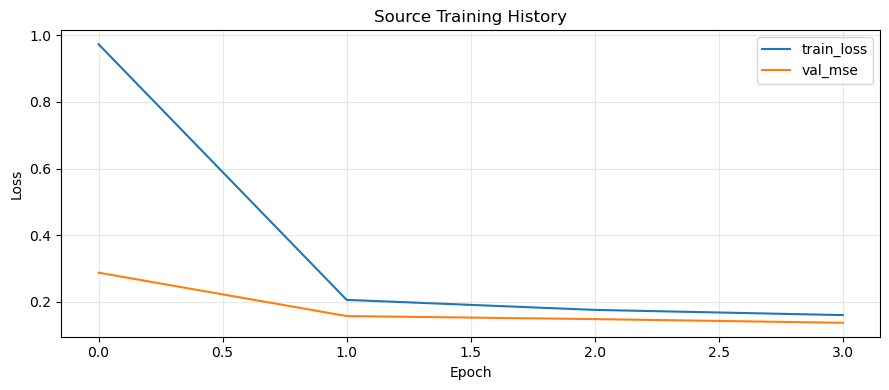

In [ ]:
source_batch_size = int(min(SOURCE_CONFIG['batch_size'], max(2, len(X_src_tr))))

source_model = TabNetRegressor(
    n_d=SOURCE_CONFIG['n_d'],
    n_a=SOURCE_CONFIG['n_d'],
    n_steps=SOURCE_CONFIG['n_steps'],
    momentum=SOURCE_CONFIG['momentum'],
    lambda_sparse=SOURCE_CONFIG['lambda_sparse'],
    optimizer_params={'lr': SOURCE_CONFIG['lr']},
    seed=RANDOM_SEED,
    device_name=TABNET_DEVICE_NAME,
    verbose=1
)

source_model.fit(
    X_src_tr, y_src_tr,
    eval_set=[(X_src_val, y_src_val)],
    eval_metric=['mse'],
    max_epochs=SOURCE_MAX_EPOCHS,
    patience=SOURCE_PATIENCE,
    batch_size=source_batch_size,
    virtual_batch_size=max(8, source_batch_size // 4),
    drop_last=True
)

source_zip_base = f'{OUTPUT_DIR}/source_model_tabnet'
source_model.save_model(source_zip_base)
SOURCE_MODEL_ZIP = f'{source_zip_base}.zip'

best_src_val = float(np.min(source_model.history['val_0_mse']))
print('Source model saved:', SOURCE_MODEL_ZIP)
print('Best source val mse:', best_src_val)

plt.figure(figsize=(9, 4))
plt.plot(source_model.history['loss'], label='train_loss')
plt.plot(source_model.history['val_0_mse'], label='val_mse')
plt.title('Source Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

Source model on NGA test
R2=0.867388 | MAE=0.339139 | RMSE=0.440675 | MAPE=149.470%


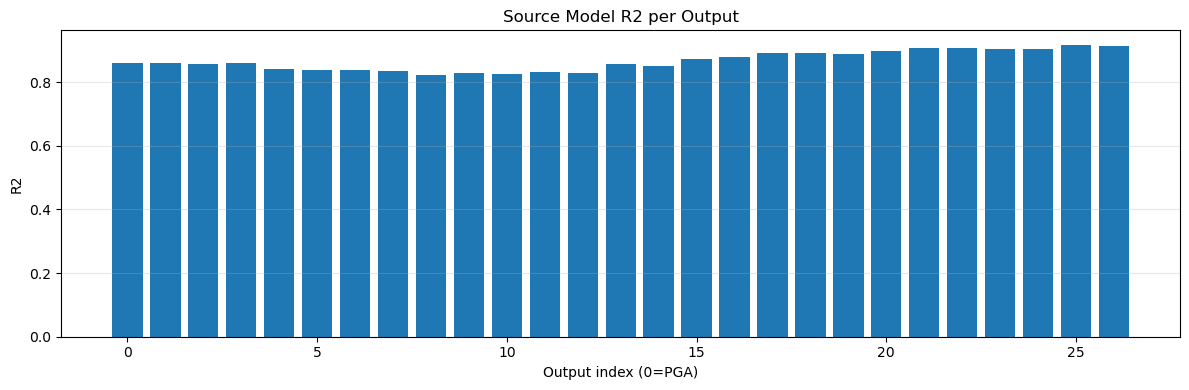

In [7]:
def evaluate_predictions(y_true_scaled, y_pred_scaled, scaler_y, label):
    y_true_log = scaler_y.inverse_transform(y_true_scaled)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled)
    y_true_org = 10 ** y_true_log
    y_pred_org = 10 ** y_pred_log

    mae = mean_absolute_error(y_true_log, y_pred_log)
    mse = mean_squared_error(y_true_log, y_pred_log)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true_log, y_pred_log)
    mape = float(np.mean(np.abs((y_true_org - y_pred_org) / (y_true_org + 1e-12))) * 100)
    r2_per_out = [r2_score(y_true_log[:, i], y_pred_log[:, i]) for i in range(y_true_log.shape[1])]

    print(label)
    print(f'R2={r2:.6f} | MAE={mae:.6f} | RMSE={rmse:.6f} | MAPE={mape:.3f}%')
    return {
        'label': label,
        'r2': float(r2),
        'mae': float(mae),
        'mse': float(mse),
        'rmse': float(rmse),
        'mape': float(mape),
        'r2_per_output': [float(v) for v in r2_per_out],
        'y_true_log': y_true_log,
        'y_pred_log': y_pred_log
    }

src_pred_test_scaled = source_model.predict(X_src_test_scaled)
src_eval = evaluate_predictions(y_src_test_scaled, src_pred_test_scaled, scaler_y, 'Source model on NGA test')

plt.figure(figsize=(12, 4))
plt.bar(np.arange(len(src_eval['r2_per_output'])), src_eval['r2_per_output'])
plt.title('Source Model R2 per Output')
plt.xlabel('Output index (0=PGA)')
plt.ylabel('R2')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/source_r2_per_output.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def build_transfer_model_from_source(source_zip, cfg):
    m = TabNetRegressor(
        n_d=SOURCE_CONFIG['n_d'],
        n_a=SOURCE_CONFIG['n_d'],
        n_steps=SOURCE_CONFIG['n_steps'],
        momentum=SOURCE_CONFIG['momentum'],
        lambda_sparse=cfg['lambda_sparse'],
        optimizer_params={'lr': cfg['lr']},
        seed=RANDOM_SEED,
        device_name=TABNET_DEVICE_NAME,
        verbose=0
    )
    m.load_model(source_zip)
    return m

def set_trainable_tensors(model, unfreeze_tensors):
    params = list(model.network.parameters())
    for p in params:
        p.requires_grad = False
    if unfreeze_tensors == 'all':
        for p in params:
            p.requires_grad = True
    else:
        k = int(unfreeze_tensors)
        for p in params[-k:]:
            p.requires_grad = True

def predict_scaled_network(model, X_scaled, batch_size=2048):
    model.network.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(X_scaled), batch_size):
            xb = torch.tensor(X_scaled[i:i+batch_size], dtype=torch.float32, device=device)
            out = model.network(xb)
            yp = out[0] if isinstance(out, tuple) else out
            outs.append(yp.detach().cpu().numpy())
    return np.vstack(outs)

def train_transfer_model(model, Xtr, ytr, Xval, yval, cfg, epochs):
    model.network.to(device)
    set_trainable_tensors(model, cfg['unfreeze_tensors'])
    trainable = [p for p in model.network.parameters() if p.requires_grad]
    if len(trainable) == 0:
        raise RuntimeError('No trainable parameters after freezing/unfreezing.')

    optimizer = optim.Adam(trainable, lr=cfg['lr'])
    criterion = nn.MSELoss()

    ds = TensorDataset(torch.tensor(Xtr, dtype=torch.float32), torch.tensor(ytr, dtype=torch.float32))
    dl = DataLoader(ds, batch_size=int(cfg['batch_size']), shuffle=True, drop_last=False)

    Xval_t = torch.tensor(Xval, dtype=torch.float32, device=device)
    yval_t = torch.tensor(yval, dtype=torch.float32, device=device)

    hist_train, hist_val = [], []
    for _ in range(epochs):
        model.network.train()
        run_loss = 0.0
        seen = 0
        for xb, yb in dl:
            # TabNet uses BatchNorm in training mode; singleton batches can trigger runtime errors.
            if xb.size(0) < 2:
                continue
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            out = model.network(xb)
            yp = out[0] if isinstance(out, tuple) else out
            loss = criterion(yp, yb)
            loss.backward()
            optimizer.step()
            run_loss += float(loss.item()) * xb.size(0)
            seen += xb.size(0)

        train_loss = run_loss / max(seen, 1)
        model.network.eval()
        with torch.no_grad():
            vout = model.network(Xval_t)
            vyp = vout[0] if isinstance(vout, tuple) else vout
            vloss = float(criterion(vyp, yval_t).item())

        hist_train.append(train_loss)
        hist_val.append(vloss)

    return hist_train, hist_val

param_names = list(TRANSFER_SPACE.keys())
param_values = [TRANSFER_SPACE[p] for p in param_names]
all_cfgs = [dict(zip(param_names, vals)) for vals in itertools.product(*param_values)]
rng = np.random.default_rng(RANDOM_SEED)
idx = rng.choice(len(all_cfgs), size=min(SWEEP_RUNS, len(all_cfgs)), replace=False)
sampled_cfgs = [all_cfgs[i] for i in idx]

sweep_results = []
for i, cfg in enumerate(sampled_cfgs, 1):
    m = build_transfer_model_from_source(SOURCE_MODEL_ZIP, cfg)
    train_hist, val_hist = train_transfer_model(
        m, X_him_tr, y_him_tr, X_him_val, y_him_val, cfg, SWEEP_EPOCHS
    )
    y_pred_scaled = predict_scaled_network(m, X_him_test_scaled)
    eval_res = evaluate_predictions(y_him_test_scaled, y_pred_scaled, scaler_y, f'Sweep cfg {i}')
    sweep_results.append({
        'cfg': cfg,
        'r2': eval_res['r2'],
        'mae': eval_res['mae'],
        'rmse': eval_res['rmse'],
        'last_train_loss': train_hist[-1],
        'last_val_loss': val_hist[-1]
    })

best_sweep = max(sweep_results, key=lambda x: x['r2'])
best_cfg = best_sweep['cfg']
print('Best transfer cfg:', best_cfg)
print('Best sweep R2:', best_sweep['r2'])
with open(f'{OUTPUT_DIR}/transfer_sweep_results.json', 'w', encoding='utf-8') as f:
    json.dump(sweep_results, f, indent=2)

c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Sweep cfg 1
R2=-0.090146 | MAE=0.534913 | RMSE=0.719213 | MAPE=186.312%


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Sweep cfg 2
R2=0.399092 | MAE=0.426224 | RMSE=0.563125 | MAPE=291.207%
Best transfer cfg: {'lr': 0.003, 'batch_size': 64, 'lambda_sparse': 1e-05, 'unfreeze_tensors': 'all'}
Best sweep R2: 0.39909228682518005


c:\Users\suggu\miniconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


Successfully saved model at results/tabnet-himalaya/final_transfer_model.zip
Final transfer epochs: 4
Model saved: results/tabnet-himalaya/final_transfer_model.zip


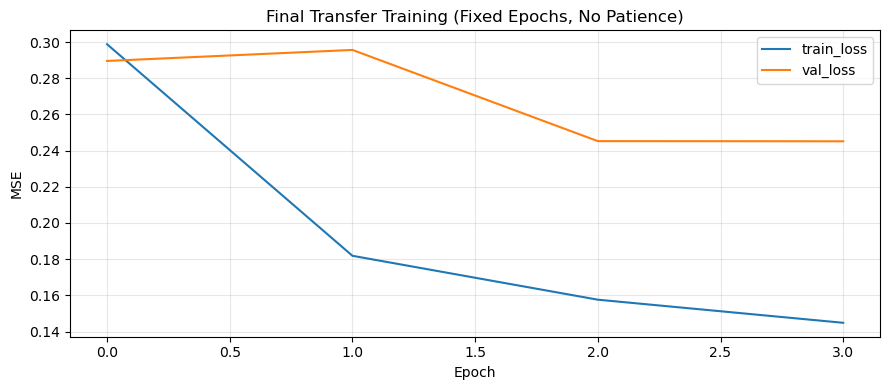

In [9]:
final_transfer_model = build_transfer_model_from_source(SOURCE_MODEL_ZIP, best_cfg)
final_train_hist, final_val_hist = train_transfer_model(
    final_transfer_model, X_him_tr, y_him_tr, X_him_val, y_him_val, best_cfg, FINAL_TRANSFER_EPOCHS
)

final_transfer_model.save_model(f'{OUTPUT_DIR}/final_transfer_model')
print('Final transfer epochs:', FINAL_TRANSFER_EPOCHS)
print('Model saved:', f'{OUTPUT_DIR}/final_transfer_model.zip')

plt.figure(figsize=(9, 4))
plt.plot(final_train_hist, label='train_loss')
plt.plot(final_val_hist, label='val_loss')
plt.title('Final Transfer Training (Fixed Epochs, No Patience)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/transfer_final_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

Final transfer model on Himalayan test
R2=0.408557 | MAE=0.421902 | RMSE=0.560617 | MAPE=1040.147%


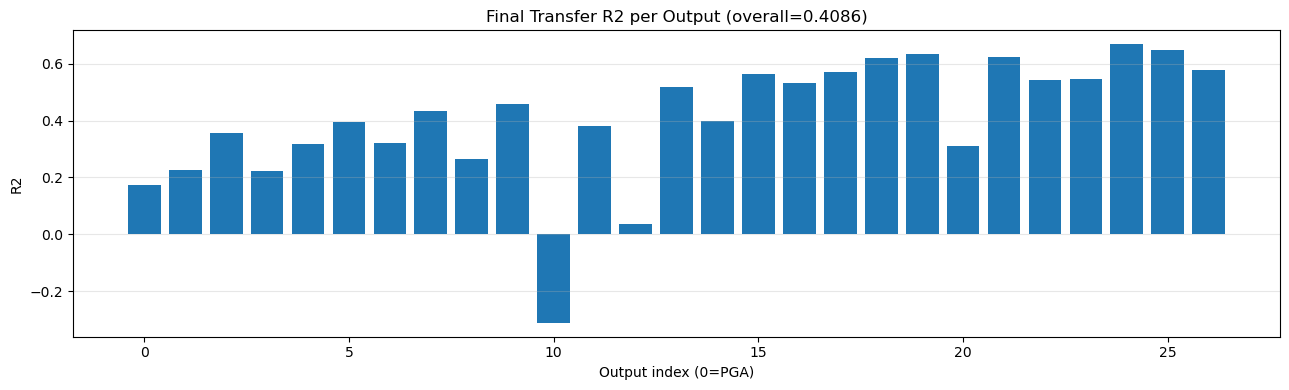

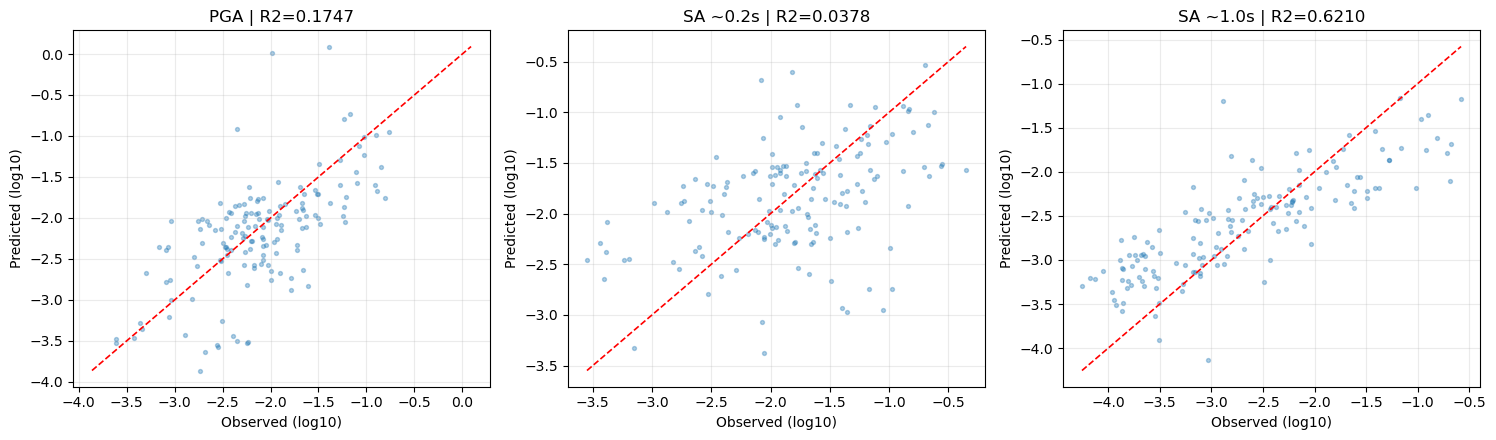

Saved metrics to transfer_eval_metrics.json


In [ ]:
final_pred_scaled = predict_scaled_network(final_transfer_model, X_him_test_scaled)
final_eval = evaluate_predictions(y_him_test_scaled, final_pred_scaled, scaler_y, 'Final transfer model on Himalayan test')

y_true_log = final_eval['y_true_log']
y_pred_log = final_eval['y_pred_log']
r2_per_output = final_eval['r2_per_output']
rmse_per_output = [float(np.sqrt(mean_squared_error(y_true_log[:, i], y_pred_log[:, i]))) for i in range(y_true_log.shape[1])]
residuals_log = y_true_log - y_pred_log

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#27AE60' if v >= 0.9 else '#F39C12' if v >= 0.7 else '#E74C3C' for v in r2_per_output]
ax.bar(np.arange(len(r2_per_output)), r2_per_output, color=colors, edgecolor='white', linewidth=0.4)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1.5, label='R2=0.90')
ax.axhline(0.7, color='darkorange', linestyle='--', linewidth=1.5, label='R2=0.70')
ax.set_xlabel('Output index (0=PGA)')
ax.set_ylabel('R2')
ax.set_title(f'Final Transfer R2 per Output (overall={final_eval["r2"]:.4f})')
ax.set_ylim(max(0, min(r2_per_output) - 0.05), 1.02)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/transfer_eval_r2_per_output.png', dpi=150, bbox_inches='tight')
plt.show()

idx_sa02 = 1 + int(np.argmin(np.abs(sa_periods - 0.2)))
idx_sa10 = 1 + int(np.argmin(np.abs(sa_periods - 1.0)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, idx, title in zip(axes, [0, idx_sa02, idx_sa10], ['PGA', 'SA ~0.2s', 'SA ~1.0s']):
    lo = min(y_true_log[:, idx].min(), y_pred_log[:, idx].min())
    hi = max(y_true_log[:, idx].max(), y_pred_log[:, idx].max())
    ax.scatter(y_true_log[:, idx], y_pred_log[:, idx], s=8, alpha=0.35)
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2)
    ax.set_title(f'{title} | R2={r2_per_output[idx]:.4f}')
    ax.set_xlabel('Observed (log10)')
    ax.set_ylabel('Predicted (log10)')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/transfer_eval_pred_vs_obs.png', dpi=150, bbox_inches='tight')
plt.show()

metrics_payload = {
    'overall_r2': final_eval['r2'],
    'overall_mae': final_eval['mae'],
    'overall_rmse': final_eval['rmse'],
    'overall_mape': final_eval['mape'],
    'mean_r2_per_output': float(np.mean(r2_per_output)),
    'min_r2_per_output': float(np.min(r2_per_output)),
    'max_r2_per_output': float(np.max(r2_per_output))
}
with open(f'{OUTPUT_DIR}/transfer_eval_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_payload, f, indent=2)
print('Saved metrics to transfer_eval_metrics.json')

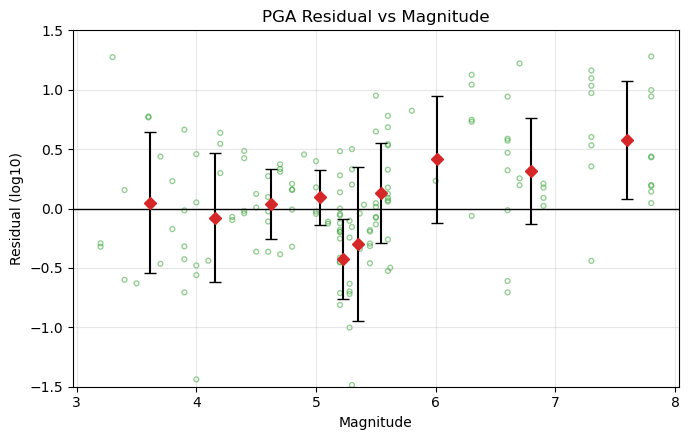

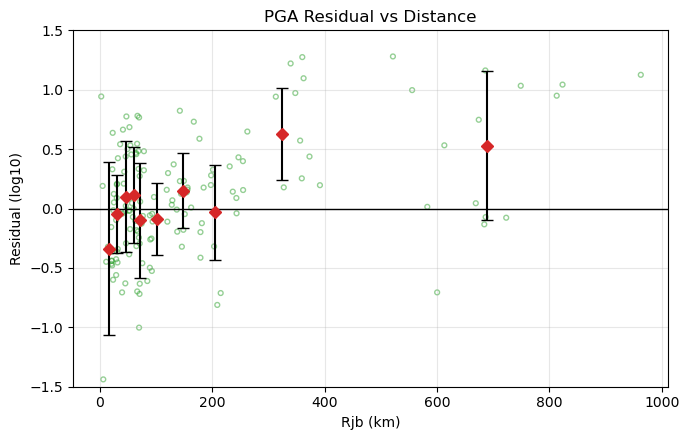

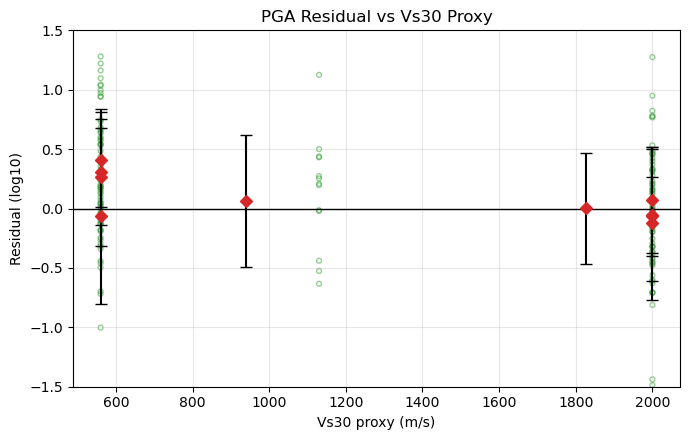

In [11]:
def equal_count_bins(x, y, n_bins=10):
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    groups = np.array_split(np.arange(len(xs)), n_bins)
    centers, means, stds = [], [], []
    for g in groups:
        if len(g) < 2:
            continue
        xg, yg = xs[g], ys[g]
        centers.append(np.mean(xg))
        means.append(np.mean(yg))
        stds.append(np.std(yg, ddof=1))
    return np.array(centers), np.array(means), np.array(stds)

pga_resid = residuals_log[:, 0]
idx_mag = input_cols.index('Earthquake Magnitude')
idx_rjb = input_cols.index('Joyner-Boore Dist. (km)')
idx_vs30_proxy = input_cols.index('log10_Vs30_proxy')
Mw = X_him_test_raw[:, idx_mag]
Rjb = X_him_test_raw[:, idx_rjb]
Vs30_proxy_log = X_him_test_raw[:, idx_vs30_proxy]
Vs30_proxy = 10 ** Vs30_proxy_log

def residual_plot(x, y, xlabel, title, fpath):
    plt.figure(figsize=(7, 4.5))
    plt.scatter(x, y, s=12, facecolors='none', edgecolors='tab:green', alpha=0.5)
    c, m, s = equal_count_bins(x, y, n_bins=10)
    plt.errorbar(c, m, yerr=s, fmt='D', color='tab:red', ecolor='black', capsize=4)
    plt.axhline(0.0, color='black', linewidth=1)
    plt.ylim(-1.5, 1.5)
    plt.xlabel(xlabel)
    plt.ylabel('Residual (log10)')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()

residual_plot(Mw, pga_resid, 'Magnitude', 'PGA Residual vs Magnitude', f'{OUTPUT_DIR}/residual_pga_magnitude.png')
mask = Rjb > 0.1
residual_plot(Rjb[mask], pga_resid[mask], 'Rjb (km)', 'PGA Residual vs Distance', f'{OUTPUT_DIR}/residual_pga_distance.png')
residual_plot(Vs30_proxy, pga_resid, 'Vs30 proxy (m/s)', 'PGA Residual vs Vs30 Proxy', f'{OUTPUT_DIR}/residual_pga_vs30_proxy.png')

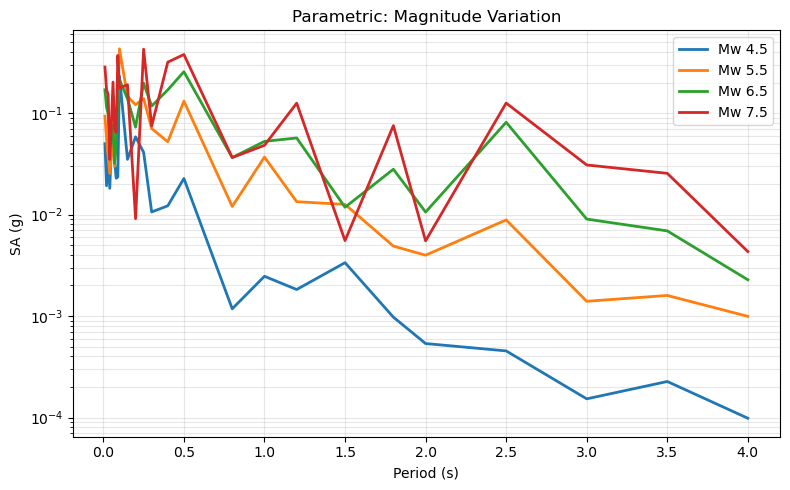

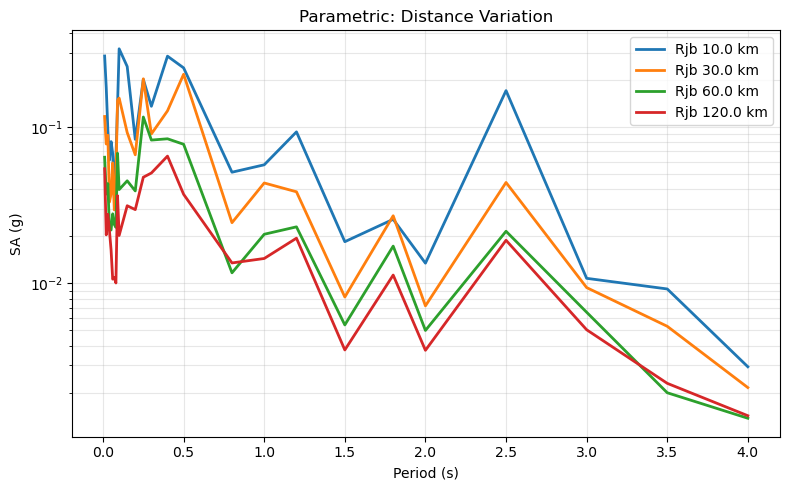

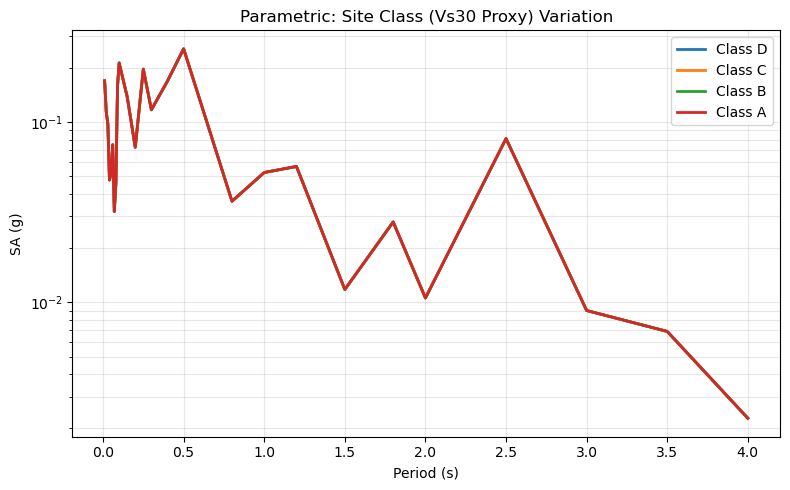

In [ ]:
def predict_spectrum(Mw, Rjb, mechanism, nehrp_class):
    nehrp_class = str(nehrp_class).strip().upper()
    if nehrp_class not in CLASS_MEAN_VS30:
        raise ValueError(f'Invalid NEHRP class: {nehrp_class}')

    vs30_proxy = float(CLASS_MEAN_VS30[nehrp_class])
    nehrp_encoded = float(NEHRP_TO_INT[nehrp_class])
    x_raw = np.array([[Mw, Rjb, mechanism, nehrp_encoded, np.log10(vs30_proxy), np.log10(Rjb)]], dtype='float32')
    x_scaled = scaler_X.transform(x_raw)
    y_scaled = predict_scaled_network(final_transfer_model, x_scaled)
    y_log = scaler_y.inverse_transform(y_scaled)
    y_lin = 10 ** y_log
    return y_lin[0, 1:]

def plot_parametric(curves, title, fpath):
    plt.figure(figsize=(8, 5))
    for label, y in curves:
        plt.semilogy(sa_periods, y, linewidth=2, label=label)
    plt.xlabel('Period (s)')
    plt.ylabel('SA (g)')
    plt.title(title)
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()

mag_curves = [(f'Mw {m}', predict_spectrum(m, 20.0, 1.0, 'B')) for m in [4.5, 5.5, 6.5, 7.5]]
plot_parametric(mag_curves, 'Parametric: Magnitude Variation', f'{OUTPUT_DIR}/parametric_magnitude.png')

dist_curves = [(f'Rjb {r} km', predict_spectrum(6.5, r, 1.0, 'B')) for r in [10.0, 30.0, 60.0, 120.0]]
plot_parametric(dist_curves, 'Parametric: Distance Variation', f'{OUTPUT_DIR}/parametric_distance.png')

vs30_curves = [(f'Class {c}', predict_spectrum(6.5, 20.0, 1.0, c)) for c in ['D', 'C', 'B', 'A']]
plot_parametric(vs30_curves, 'Parametric: Site Class (Vs30 Proxy) Variation', f'{OUTPUT_DIR}/parametric_vs30_proxy_class.png')

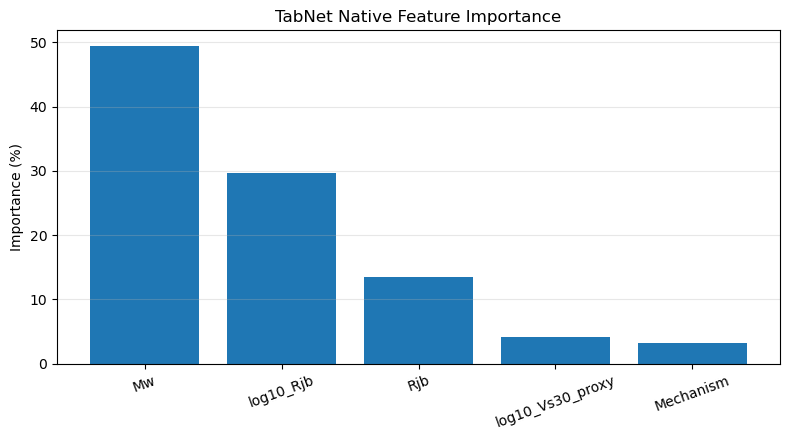

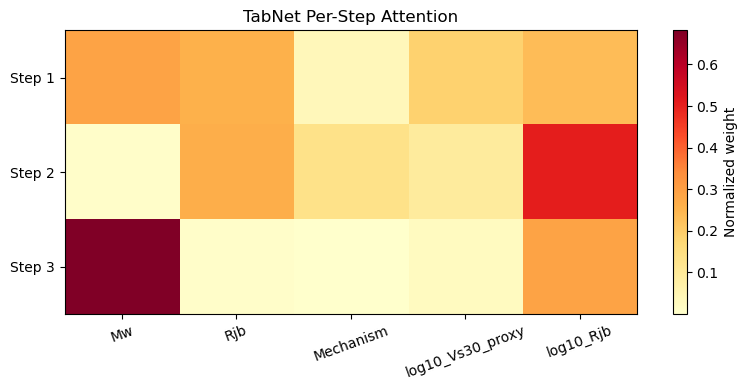

In [ ]:
M_explain, masks = final_transfer_model.explain(X_him_test_scaled)
feature_names = [
    'Mw',
    'Rjb',
    'Mechanism',
    'NEHRP_Class_Encoded',
    'log10_Vs30_proxy',
    'log10_Rjb'
 ]

mean_attention = M_explain.mean(axis=0)
importance_pct = 100.0 * mean_attention / (mean_attention.sum() + 1e-12)
order = np.argsort(importance_pct)[::-1]

plt.figure(figsize=(8, 4.5))
plt.bar(np.arange(len(feature_names)), importance_pct[order])
plt.xticks(np.arange(len(feature_names)), [feature_names[i] for i in order], rotation=20)
plt.ylabel('Importance (%)')
plt.title('TabNet Native Feature Importance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tabnet_native_importance.png', dpi=150, bbox_inches='tight')
plt.show()

step_means = np.array([masks[k].mean(axis=0) for k in sorted(masks.keys())])
step_norm = step_means / (step_means.sum(axis=1, keepdims=True) + 1e-12)
plt.figure(figsize=(8, 4))
plt.imshow(step_norm, aspect='auto', cmap='YlOrRd')
plt.yticks(np.arange(step_norm.shape[0]), [f'Step {i+1}' for i in range(step_norm.shape[0])])
plt.xticks(np.arange(len(feature_names)), feature_names, rotation=20)
plt.title('TabNet Per-Step Attention')
plt.colorbar(label='Normalized weight')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tabnet_attention_steps.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\suggu\miniconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: Sparsemax
  warnings.warn(f"unrecognized nn.Module: {module_type}")
c:\Users\suggu\miniconda3\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: EmbeddingGenerator
  warnings.warn(f"unrecognized nn.Module: {module_type}")


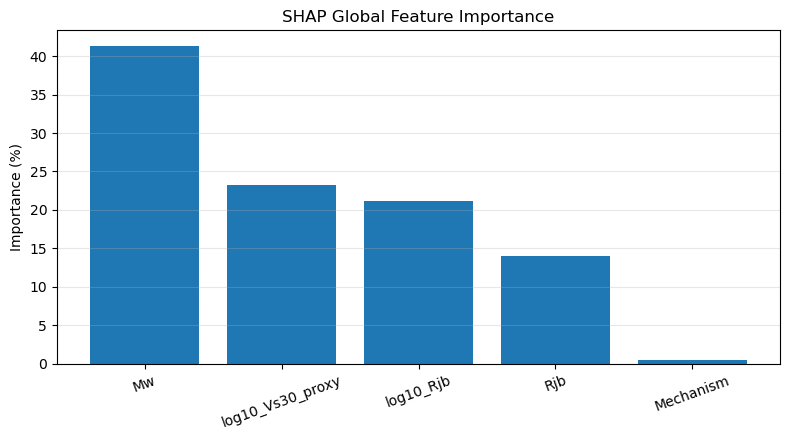

C:\Users\suggu\AppData\Local\Temp\ipykernel_1808\278904276.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list[oi], x_exp_np, feature_names=feature_names, plot_type='dot', show=False)


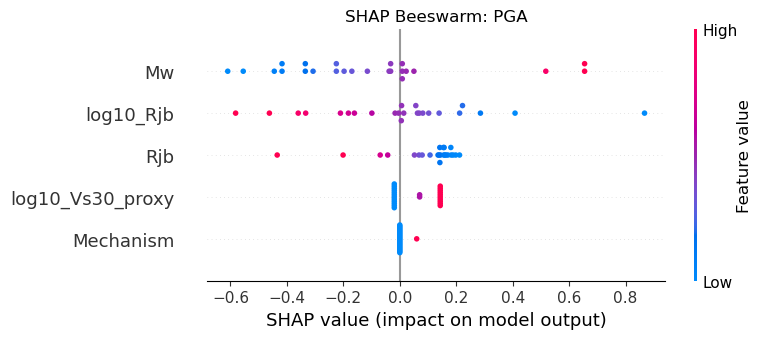

C:\Users\suggu\AppData\Local\Temp\ipykernel_1808\278904276.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list[oi], x_exp_np, feature_names=feature_names, plot_type='dot', show=False)


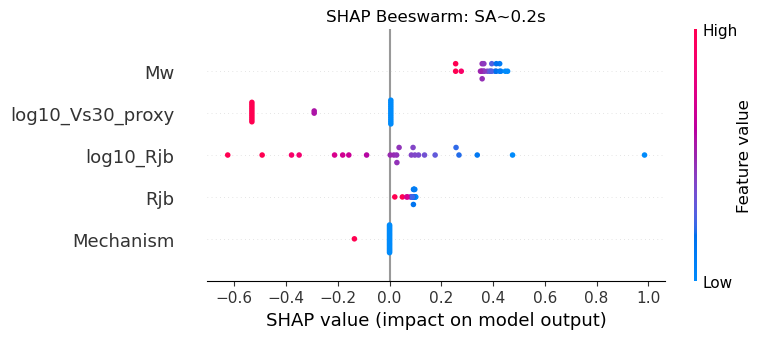

C:\Users\suggu\AppData\Local\Temp\ipykernel_1808\278904276.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list[oi], x_exp_np, feature_names=feature_names, plot_type='dot', show=False)


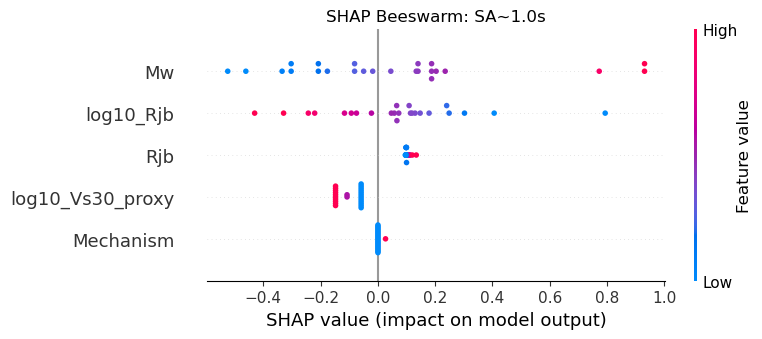

Notebook pipeline complete.


In [ ]:
class NetWrapper(nn.Module):
    def __init__(self, network):
        super().__init__()
        self.network = network
    def forward(self, x):
        out = self.network(x)
        return out[0] if isinstance(out, tuple) else out

final_transfer_model.network.eval()
model_device = next(final_transfer_model.network.parameters()).device

bg_n = min(256, len(X_him_tr))
exp_n = min(400, len(X_him_test_scaled))
rng = np.random.default_rng(RANDOM_SEED)
bg_idx = rng.choice(len(X_him_tr), size=bg_n, replace=False)
exp_idx = rng.choice(len(X_him_test_scaled), size=exp_n, replace=False)

background = torch.tensor(X_him_tr[bg_idx], dtype=torch.float32).to(model_device)
x_exp_t = torch.tensor(X_him_test_scaled[exp_idx], dtype=torch.float32).to(model_device)
x_exp_np = X_him_test_scaled[exp_idx]

shap_ok = True
try:
    explainer = shap.DeepExplainer(NetWrapper(final_transfer_model.network), background)
    shap_values = explainer.shap_values(x_exp_t, check_additivity=False)
except Exception as e:
    shap_ok = False
    print('SHAP skipped due to runtime issue:', str(e))

if shap_ok:
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
    elif isinstance(shap_values, list):
        shap_list = shap_values
    else:
        raise ValueError('Unexpected SHAP value format.')

    shap_global = np.mean([np.abs(sv).mean(axis=0) for sv in shap_list], axis=0)
    shap_pct = 100.0 * shap_global / (shap_global.sum() + 1e-12)
    order = np.argsort(shap_pct)[::-1]

    plt.figure(figsize=(8, 4.5))
    plt.bar(np.arange(len(feature_names)), shap_pct[order])
    plt.xticks(np.arange(len(feature_names)), [feature_names[i] for i in order], rotation=20)
    plt.ylabel('Importance (%)')
    plt.title('SHAP Global Feature Importance')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/shap_global_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    key_outputs = [0, 1 + int(np.argmin(np.abs(sa_periods - 0.2))), 1 + int(np.argmin(np.abs(sa_periods - 1.0)))]
    key_names = ['PGA', 'SA~0.2s', 'SA~1.0s']
    for oi, oname in zip(key_outputs, key_names):
        plt.figure(figsize=(8, 4.5))
        shap.summary_plot(shap_list[oi], x_exp_np, feature_names=feature_names, plot_type='dot', show=False)
        plt.title(f'SHAP Beeswarm: {oname}')
        plt.tight_layout()
        plt.savefig(f'{OUTPUT_DIR}/shap_beeswarm_{oname.replace("~", "_")}.png', dpi=150, bbox_inches='tight')
        plt.show()

print('Notebook pipeline complete.')